### Import statement

In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from netCDF4 import Dataset

from cmcrameri import cm
import scienceplots
plt.style.use(['science', 'no-latex'])  # Use 'science' style without LaTeX rendering
plt.rcParams.update({"font.size":15})

In [77]:
nc_file_path = "/home/marijn/LovePy/fwlLove.jl/out/obliqua_data.nc"
interior_dat = "/home/marijn/PROTEUS/Obliqua_data/output272353.0.json"
out_dir      = "/home/marijn/LovePy/fwlLove.jl/out"

if not os.path.exists(nc_file_path):
    raise FileNotFoundError(f"Could not find NetCDF file at {nc_file_path}")
    
ds = Dataset(nc_file_path, "r")
os.makedirs(out_dir, exist_ok=True)

### Plot Global Love numbers

In [78]:
def plot_imagk2_spectrum(sigma_range, imag_k2, n=2, outpath=None):
    """
    Plots the Imk2 Love numbers with a detailed, 
    custom loglog-style grid matrix.
    """
    # manually compute logs for linear scattering
    sigma_range = np.log10(np.abs(sigma_range))
    imag_k2     = np.log10(np.abs(imag_k2))
                           
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.scatter(sigma_range, imag_k2) 
        
    ax.set_title(r"Imag($k_{" + str(n) + r"}$) Spectrum")
    ax.set_xlabel(r"$\log_{10}(\sigma)$ [Hz]")
    ax.set_ylabel(r"$\log_{10}(\text{Imag}(k_{" + str(n) + r"}))$")
    
    # SYNTHETIC LOG-LOG GRID MATRICES
    # major ticks at every whole decade integer (-1.0, -2.0, etc.)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    
    # minor ticks to simulate log-spacing intervals between decades
    # log10 of intermediate steps (2, 3, 4...) approximate these fractional steps:
    log_subs = np.log10([2, 3, 4, 5, 6, 7, 8, 9])
    
    # generate ticks across the typical log-data spectrum dynamically
    minor_ticks_x = np.concatenate([np.arange(np.floor(sigma_range.min()), np.ceil(sigma_range.max())) + sub for sub in log_subs])
    minor_ticks_y = np.concatenate([np.arange(np.floor(imag_k2.min()), np.ceil(imag_k2.max())) + sub for sub in log_subs])
    
    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_x))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_y))
    
    # render major lines solid and distinct; minor lines fine and tightly grouped
    ax.grid(True, which="major", ls="-", color='#444444', alpha=0.4, zorder=1)
    ax.grid(True, which="minor", ls=":", color='#888888', alpha=0.25, zorder=1)
    
    ax.legend(loc="best")
        
    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

/tmp/ipykernel_3746434/3745996484.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


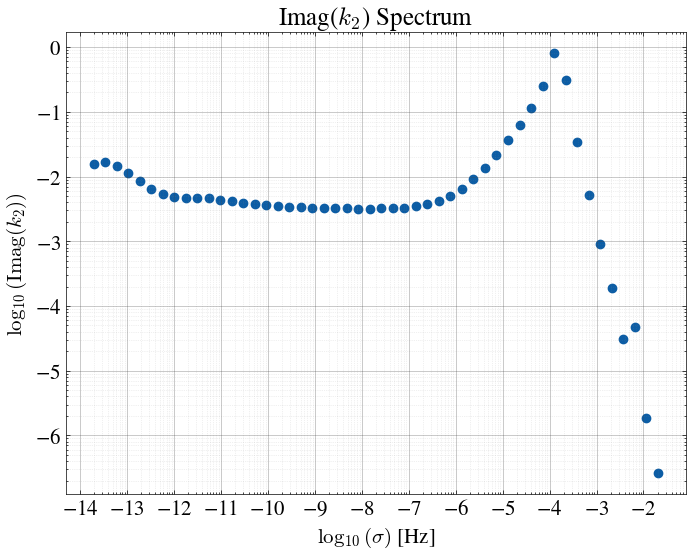

In [79]:
# read shared dimensions
sigma_range = ds.variables["sigma_range"][:]
n           = ds.variables["n"][:]

# extract and run plot
raw_imag   = ds.variables["knms_total"]
knms_total = raw_imag[0, :] + 1j * raw_imag[1, :]

# loop over unique n values and plot each spectrum separately
for n_i in np.unique(n):

    knms_total_n = knms_total[n == n_i]

    fig = plot_imagk2_spectrum(
        sigma_range=sigma_range, 
        imag_k2=-np.imag(knms_total_n), 
        n=n_i,
        outpath=os.path.join(out_dir, f"all_layers_k{n_i}.png")
    )

### Plot Section-wise Love Numbers

In [80]:
def plot_imagk2_spectra(sigma_range, imag_k2, segments, n=2, outpath=None):
    """
    Plots the segment-wise Imk2 Love numbers with a detailed, 
    custom loglog-style grid matrix.
    """
    # manually compute logs for linear scattering
    sigma_range = np.log10(np.abs(sigma_range))
    imag_k2     = np.log10(np.abs(imag_k2))
                           
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = cm.batlow(np.linspace(0, 1, len(segments)))
    
    for idx, seg_name in enumerate(segments):
        ax.scatter(sigma_range, imag_k2[idx, :], label=seg_name, 
                  color=colors[idx], s=50, zorder=3) # zorder keeps points on top of grid lines
        
    ax.set_title(r"Imag($k_{" + str(n) + r"}$) Spectrum")
    ax.set_xlabel(r"$\log_{10}(\sigma)$ [Hz]")
    ax.set_ylabel(r"$\log_{10}(\text{Imag}(k_{" + str(n) + r"}))$")
    
    # SYNTHETIC LOG-LOG GRID MATRICES
    # major ticks at every whole decade integer (-1.0, -2.0, etc.)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    
    # minor ticks to simulate log-spacing intervals between decades
    # log10 of intermediate steps (2, 3, 4...) approximate these fractional steps:
    log_subs = np.log10([2, 3, 4, 5, 6, 7, 8, 9])
    
    # generate ticks across the typical log-data spectrum dynamically
    minor_ticks_x = np.concatenate([np.arange(np.floor(sigma_range.min()), np.ceil(sigma_range.max())) + sub for sub in log_subs])
    minor_ticks_y = np.concatenate([np.arange(np.floor(imag_k2.min()), np.ceil(imag_k2.max())) + sub for sub in log_subs])
    
    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_x))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks_y))
    
    # render major lines solid and distinct; minor lines fine and tightly grouped
    ax.grid(True, which="major", ls="-", color='#444444', alpha=0.4, zorder=1)
    ax.grid(True, which="minor", ls=":", color='#888888', alpha=0.25, zorder=1)
    
    ax.legend(loc="best")
        
    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

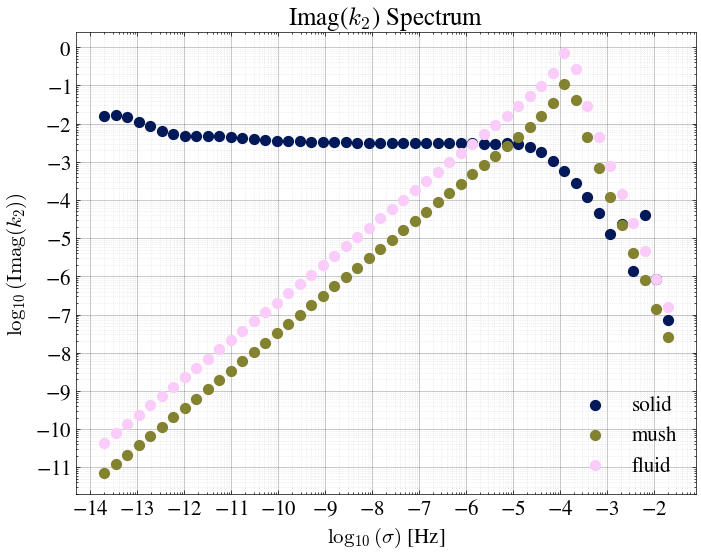

In [81]:
# read shared dimensions
sigma_range = ds.variables["sigma_range"][:]
n           = ds.variables["n"][:]

# extract and run plot
raw_imag = ds.variables["knms_T"]
Knms_T   = raw_imag[0, :, :] + 1j * raw_imag[1, :, :]
segments = ds.variables["segment_lbl"][:]

# loop over unique n values and plot each spectrum separately
for n_i in np.unique(n):

    Knms_T_n = Knms_T[:, n == n_i]

    fig = plot_imagk2_spectra(
        sigma_range=sigma_range, 
        imag_k2=-np.imag(Knms_T_n), 
        segments=segments,
        n=n_i,
        outpath=os.path.join(out_dir, f"all_layers_k{n_i}.png")
    )

### Plot Heating profile per forcing frequency

In [82]:
def plot_segment_heating(H, sigma_range, Nz=None, mask_floor=1e-25, rotation_angle=60, outpath=None, title_str="Heating profile"):
    """
    Creates a heatmap of tidal heating values across radius and forcing frequency
    with equally-spaced structural bars and rotated true log-frequency labels.
    """
    if Nz is None:
        Nz = H.shape[0]
    
    # compute the actual log-frequencies for our labels
    actual_log_sigmas = np.log10(np.abs(sigma_range))
    
    # establish geometric indices so the pcolormesh bars have equal structural width
    bar_indices = np.arange(len(sigma_range))

    r_norm = np.linspace(0.01, 1.0, Nz)
    H_mat  = np.maximum(H, mask_floor)
            
    fig, ax = plt.subplots(figsize=(9, 5))
    X, Y = np.meshgrid(bar_indices, r_norm)
    mesh = ax.pcolormesh(X, Y, np.log10(H_mat), cmap=cm.lajolla, shading='auto')
    
    # EQUAL-WIDTH ROTATED TICK LABELLING LOGIC
    ax.set_xticks(bar_indices)
    
    # convert your actual log values into clean strings rounded to 2 decimal places
    tick_labels = [f"{val:.2f}" for val in actual_log_sigmas]
    
    # apply labels with explicit rotation and right-alignment for clean tracking
    ax.set_xticklabels(tick_labels, rotation=rotation_angle, ha="right")
    
    ax.set_title(title_str)
    ax.set_xlabel(r"Forcing frequency ($\log_{10}(\sigma)$ [Hz])")
    ax.set_ylabel("Modeled radius fraction (r / R)")
    
    ax.invert_xaxis()
    
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(r"$\log_{10}$ [Wm$^{-3}$] (tidal heating)")
    
    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

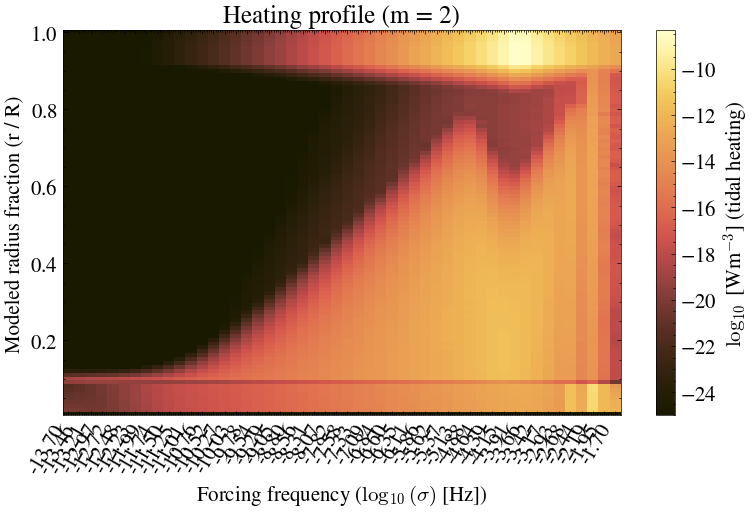

In [83]:
# read shared dimensions
sigma_range = ds.variables["sigma_range"][:]
m           = ds.variables["m"][:]

# extract and run plot
P_T_s_prf = ds.variables["P_T_s_prf"][:]
Nz        = ds.dimensions['z'].size if 'z' in ds.dimensions else None

# loop over unique m values and plot each spectrum separately
for m_i in np.unique(m):
    
    P_T_s_prf_i = P_T_s_prf[:, m == m_i]
    sigma_range_i = sigma_range[m == m_i]

    fig = plot_segment_heating(
        H=P_T_s_prf_i, 
        sigma_range=sigma_range_i, 
        Nz=Nz, 
        mask_floor=1e-25,
        outpath=os.path.join(out_dir, f"tidal_heating_map_segment_m{m_i}.png"),
        title_str="Heating profile (m = " + str(m_i) + ")"
    )

### Plot heating profile

In [84]:
def plot_heating(H, Nz=None, mask_floor=1e-25, outpath=None, title_str="Heating profile"):
    """
    Creates a heating profile of tidal heating values across radius.
    """
    if Nz is None:
        Nz = H.shape
    
    r_norm = np.linspace(0.01, 1.0, Nz)
            
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(r_norm, np.log10(H))
    
    ax.set_title(title_str)
    ax.set_xlabel("Modeled radius fraction (r / R)")
    ax.set_ylabel(r"Heating (log10 [Wm$^{-3}$])")
    
    ax.set_ylim(bottom=max(np.log10(mask_floor), np.min(np.log10(H))-1))  # Set y-axis lower limit to mask_floor

    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

/tmp/ipykernel_3746434/3873167408.py:11: RuntimeWarning: divide by zero encountered in log10
  ax.plot(r_norm, np.log10(H))
/tmp/ipykernel_3746434/3873167408.py:17: RuntimeWarning: divide by zero encountered in log10
  ax.set_ylim(bottom=max(np.log10(mask_floor), np.min(np.log10(H))-1))  # Set y-axis lower limit to mask_floor


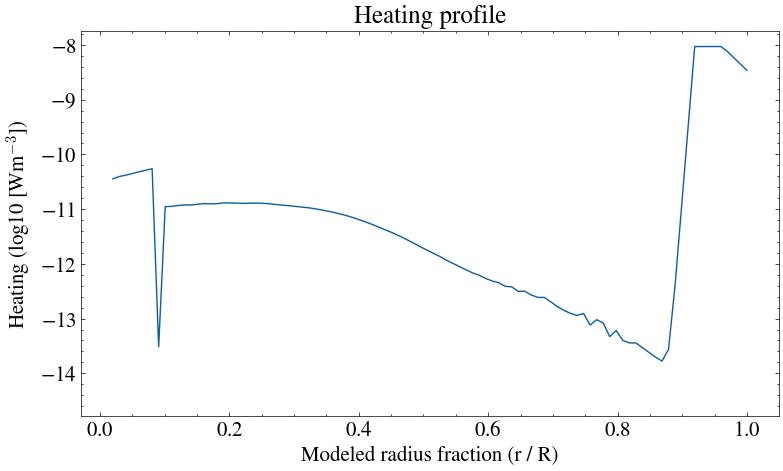

In [85]:
# extract and run plot
P_T_prf = ds.variables["P_T_prf"][:]
Nz      = ds.dimensions['z'].size if 'z' in ds.dimensions else None

fig = plot_heating(
    H=P_T_prf, 
    Nz=Nz, 
    mask_floor=1e-25,
    outpath=os.path.join(out_dir, f"tidal_heating.png"),
    title_str="Heating profile"
)

### Plot Surface heating map

In [86]:
def plot_surface_heating(H_surf_raw, lons, lats, outpath=None, title_str="Surface heating map"):
    """
    Creates a map layout of surface tidal heating across longitude and latitude coordinates.
    """
    H_surf = np.log10(H_surf_raw.T)
        
    fig, ax = plt.subplots(figsize=(10, 5))
    mesh = ax.pcolormesh(lons, lats, H_surf, cmap=cm.lajolla, shading='auto')
    
    ax.set_title(title_str)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect('equal')
    
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(r"$log_{10}$(surface heating)")
    
    if outpath:
        fig.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

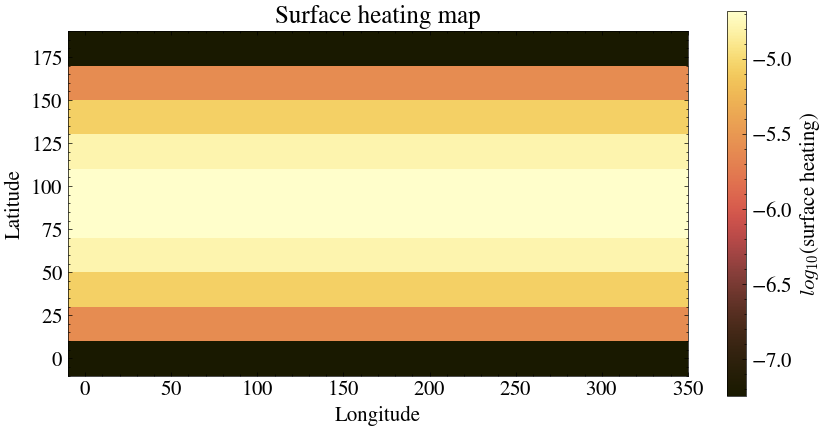

In [87]:
# extract and run plot
P_T_map = ds.variables["P_T_map"][:]
lons = ds.variables["lon"][:]
lats = ds.variables["lat"][:]

fig = plot_surface_heating(
    H_surf_raw=P_T_map, 
    lons=lons, 
    lats=lats, 
    outpath=os.path.join(out_dir, "tidal_heating_map_surface.png"),
    title_str="Surface heating map"
)